In [2]:
print("Notebook çalışıyor")

Notebook çalışıyor


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("Kütüphaneler hazır.")

Kütüphaneler hazır.


In [4]:
%pip install yfinance


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("Kütüphaneler hazır.")

Kütüphaneler hazır.


In [6]:
ticker = "AMZN"

df = yf.download(
    ticker,
    start="2010-01-01",
    end="2026-01-01",
    progress=False
)

print("Veri boyutu:", df.shape)
display(df.head())
display(df.tail())

Veri boyutu: (4024, 5)


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2010-01-04,6.6950,6.8305,6.6570,6.8125,151998000
2010-01-05,6.7345,6.7740,6.5905,6.6715,177038000
2010-01-06,6.6125,6.7365,6.5825,6.7300,143576000
2010-01-07,6.5000,6.6160,6.4400,6.6005,220604000
2010-01-08,6.6760,6.6840,6.4515,6.5280,196610000


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2025-12-24,232.380005,232.949997,231.330002,232.130005,11420500
2025-12-26,232.520004,232.990005,231.179993,232.039993,15994700
2025-12-29,232.070007,232.600006,230.770004,231.940002,19797900
2025-12-30,232.529999,232.770004,230.199997,231.210007,21910500
2025-12-31,230.820007,232.990005,230.119995,232.910004,24383700


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4024 entries, 2010-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AMZN)   4024 non-null   float64
 1   (High, AMZN)    4024 non-null   float64
 2   (Low, AMZN)     4024 non-null   float64
 3   (Open, AMZN)    4024 non-null   float64
 4   (Volume, AMZN)  4024 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 188.6 KB


In [8]:
df.isnull().sum()


Price   Ticker
Close   AMZN      0
High    AMZN      0
Low     AMZN      0
Open    AMZN      0
Volume  AMZN      0
dtype: int64

In [9]:
df.columns = df.columns.get_level_values(0)
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,6.6950,6.8305,6.6570,6.8125,151998000
2010-01-05,6.7345,6.7740,6.5905,6.6715,177038000
2010-01-06,6.6125,6.7365,6.5825,6.7300,143576000
2010-01-07,6.5000,6.6160,6.4400,6.6005,220604000
2010-01-08,6.6760,6.6840,6.4515,6.5280,196610000


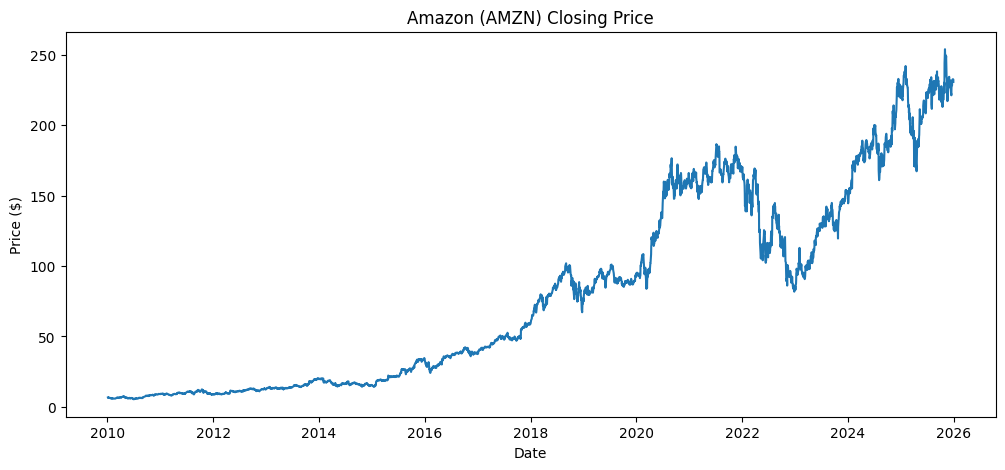

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Close"])
plt.title("Amazon (AMZN) Closing Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.show()

In [11]:
df.to_csv("../data/amzn_stock.csv")

print("Veri kaydedildi.")

Veri kaydedildi.


In [12]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Sadece kapanış fiyatını kullanıyoruz
close_data = df[["Close"]].copy()

# %80 train, %20 test
split_index = int(len(close_data) * 0.8)

train_data = close_data.iloc[:split_index]
test_data = close_data.iloc[split_index:]

# Ölçeklendirme: -1 ile 1 arasına
scaler = MinMaxScaler(feature_range=(-1, 1))

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print("Train:", train_data.shape)
print("Test:", test_data.shape)

Train: (3219, 1)
Test: (805, 1)


In [13]:
def create_sequences(data, lookback=20):
    X = []
    y = []

    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])

    return np.array(X), np.array(y)


lookback = 20

X_train, y_train = create_sequences(train_scaled, lookback)
X_test, y_test = create_sequences(test_scaled, lookback)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (3199, 20, 1)
y_train: (3199, 1)
X_test: (785, 20, 1)
y_test: (785, 1)


In [14]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_train: torch.Size([3199, 20, 1])
y_train: torch.Size([3199, 1])
X_test: torch.Size([785, 20, 1])
y_test: torch.Size([785, 1])


In [15]:
%pip install torch


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print(X_train_tensor.shape)
print(y_train_tensor.shape)
print(X_test_tensor.shape)
print(y_test_tensor.shape)

torch.Size([3199, 20, 1])
torch.Size([3199, 1])
torch.Size([785, 20, 1])
torch.Size([785, 1])


In [17]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)

        # Son zaman adımının çıktısı
        out = out[:, -1, :]

        return self.fc(out)


lstm_model = LSTMModel()

print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [18]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

epochs = 100

for epoch in range(epochs):
    lstm_model.train()

    optimizer.zero_grad()

    predictions = lstm_model(X_train_tensor)

    loss = criterion(predictions, y_train_tensor)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f}")

Epoch 10/100 - Loss: 0.471465
Epoch 20/100 - Loss: 0.258346
Epoch 30/100 - Loss: 0.193251
Epoch 40/100 - Loss: 0.092869
Epoch 50/100 - Loss: 0.043226
Epoch 60/100 - Loss: 0.031081
Epoch 70/100 - Loss: 0.019217
Epoch 80/100 - Loss: 0.008586
Epoch 90/100 - Loss: 0.005300
Epoch 100/100 - Loss: 0.004695


In [19]:
from sklearn.metrics import mean_squared_error

lstm_model.eval()

with torch.no_grad():
    test_predictions = lstm_model(X_test_tensor).numpy()

# Ölçeklenmiş değerleri tekrar gerçek dolar fiyatına çevir
predicted_prices = scaler.inverse_transform(test_predictions)
actual_prices = scaler.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

print(f"LSTM Test RMSE: ${rmse:.2f}")

LSTM Test RMSE: $27.17


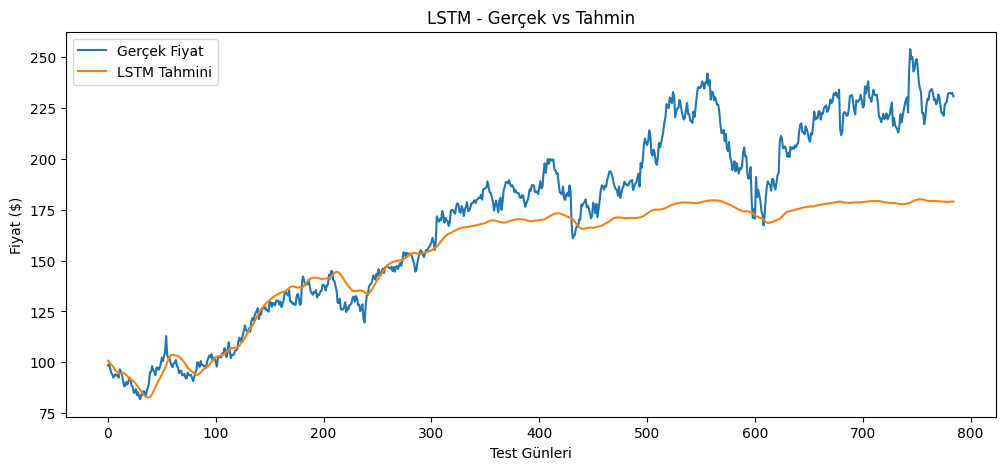

In [20]:
plt.figure(figsize=(12,5))
plt.plot(actual_prices, label="Gerçek Fiyat")
plt.plot(predicted_prices, label="LSTM Tahmini")

plt.title("LSTM - Gerçek vs Tahmin")
plt.xlabel("Test Günleri")
plt.ylabel("Fiyat ($)")
plt.legend()
plt.show()

In [21]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)


gru_model = GRUModel()
print(gru_model)

GRUModel(
  (gru): GRU(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [22]:
gru_criterion = nn.MSELoss()

gru_optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

epochs = 100

for epoch in range(epochs):
    gru_model.train()

    gru_optimizer.zero_grad()

    predictions = gru_model(X_train_tensor)

    loss = gru_criterion(predictions, y_train_tensor)

    loss.backward()
    gru_optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f}")

Epoch 10/100 - Loss: 0.399069
Epoch 20/100 - Loss: 0.235874
Epoch 30/100 - Loss: 0.164821
Epoch 40/100 - Loss: 0.057835
Epoch 50/100 - Loss: 0.002226
Epoch 60/100 - Loss: 0.008610
Epoch 70/100 - Loss: 0.001690
Epoch 80/100 - Loss: 0.002233
Epoch 90/100 - Loss: 0.001298
Epoch 100/100 - Loss: 0.001348


In [23]:
gru_model.eval()

with torch.no_grad():
    gru_test_predictions = gru_model(X_test_tensor).numpy()

gru_predicted_prices = scaler.inverse_transform(gru_test_predictions)

gru_rmse = np.sqrt(
    mean_squared_error(actual_prices, gru_predicted_prices)
)

print(f"GRU Test RMSE: ${gru_rmse:.2f}")
print(f"LSTM Test RMSE: ${rmse:.2f}")

GRU Test RMSE: $14.36
LSTM Test RMSE: $27.17


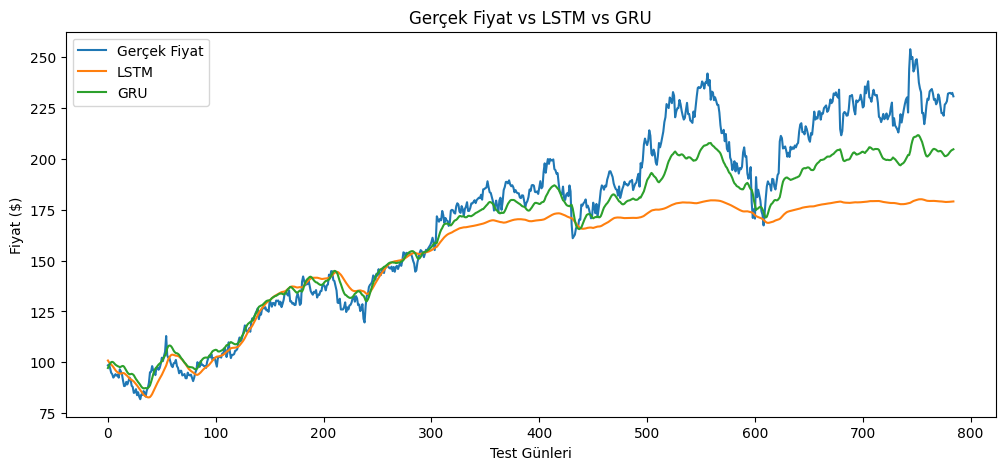

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(actual_prices, label="Gerçek Fiyat")
plt.plot(predicted_prices, label="LSTM")
plt.plot(gru_predicted_prices, label="GRU")

plt.title("Gerçek Fiyat vs LSTM vs GRU")
plt.xlabel("Test Günleri")
plt.ylabel("Fiyat ($)")
plt.legend()
plt.show()

In [25]:
results = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "RMSE": [rmse, gru_rmse]
})

results

,Model,RMSE
0,LSTM,27.173036
1,GRU,14.355319


In [26]:
results.to_csv("../results/model_comparison.csv", index=False)

print("Sonuçlar kaydedildi.")

Sonuçlar kaydedildi.


In [27]:
# Test döneminden önceki son 20 günü de dahil ediyoruz
test_input = close_data.iloc[split_index - lookback:]

# Train verisinden öğrenilmiş scaler ile dönüştürüyoruz
test_input_scaled = scaler.transform(test_input)

X_test_correct, y_test_correct = create_sequences(
    test_input_scaled,
    lookback
)

X_test_correct = torch.tensor(
    X_test_correct,
    dtype=torch.float32
)

y_test_correct = torch.tensor(
    y_test_correct,
    dtype=torch.float32
)

print("X_test:", X_test_correct.shape)
print("y_test:", y_test_correct.shape)

X_test: torch.Size([805, 20, 1])
y_test: torch.Size([805, 1])


In [28]:
lstm_model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_correct = lstm_model(X_test_correct).numpy()
    gru_correct = gru_model(X_test_correct).numpy()

actual_correct = scaler.inverse_transform(y_test_correct.numpy())
lstm_correct_prices = scaler.inverse_transform(lstm_correct)
gru_correct_prices = scaler.inverse_transform(gru_correct)

lstm_rmse_correct = np.sqrt(
    mean_squared_error(actual_correct, lstm_correct_prices)
)

gru_rmse_correct = np.sqrt(
    mean_squared_error(actual_correct, gru_correct_prices)
)

print(f"LSTM RMSE: ${lstm_rmse_correct:.2f}")
print(f"GRU RMSE: ${gru_rmse_correct:.2f}")

LSTM RMSE: $26.94
GRU RMSE: $14.30


In [29]:
results = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "RMSE": [lstm_rmse_correct, gru_rmse_correct]
})

results.to_csv("../results/model_comparison.csv", index=False)

results

,Model,RMSE
0,LSTM,26.935273
1,GRU,14.297735


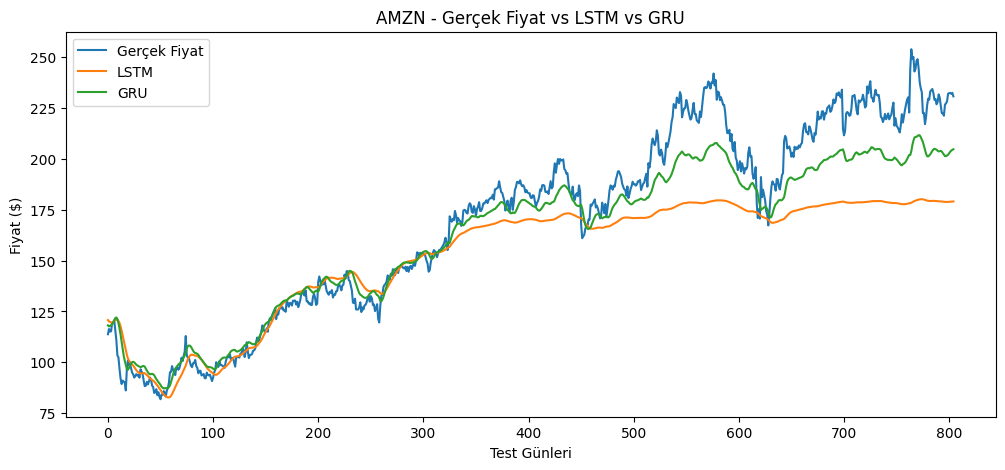

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(actual_correct, label="Gerçek Fiyat")
plt.plot(lstm_correct_prices, label="LSTM")
plt.plot(gru_correct_prices, label="GRU")

plt.title("AMZN - Gerçek Fiyat vs LSTM vs GRU")
plt.xlabel("Test Günleri")
plt.ylabel("Fiyat ($)")
plt.legend()
plt.show()